# Day 5—Measuring vowels
*Measuring Manuscripts*

We can't record Chaucer, and we can't record Coptic. So before we measure speech we can't hear, we'll measure speech we build ourselves: synthesize a vowel from a few numbers, listen to it, then measure those numbers back out. Once the tool works on a sound you control, you can trust it on a real one.

## 1. Setup

Run once. `parselmouth` is the Python interface to Praat, the standard tool for speech analysis.

In [12]:
!pip install praat-parselmouth --quiet

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import parselmouth
from IPython.display import Audio, display

fs = 16000   # sampling rate in Hz

## 2. Build a vowel from scratch

A vowel is a buzz from the vocal folds, shaped by the resonances of the mouth. We can fake exactly that: make a buzz (a pulse train at the pitch `f0`), then pass it through one resonator per **formant**. Give it the formants of */a/* and it comes out sounding like *ah*.

In [13]:
def synth_vowel(formants, f0=120, dur=0.6, fs=fs):
    """Buzz at pitch f0, shaped by one resonator per formant.
    formants: list of (frequency_Hz, bandwidth_Hz)."""
    n = int(dur * fs)
    source = np.zeros(n)
    source[::int(fs / f0)] = 1.0          # glottal pulses
    out = source.copy()
    for freq, bw in formants:
        r = np.exp(-np.pi * bw / fs)
        theta = 2 * np.pi * freq / fs
        out = lfilter([1 - r], [1, -2*r*np.cos(theta), r*r], out)
    return out / np.max(np.abs(out))

# /a/ as in 'father': (frequency, bandwidth) in Hz for each formant
a = synth_vowel([(730, 70), (1090, 70), (2440, 90), (3500, 120), (4500, 150)])
Audio(a, rate=fs)

## 3. The five vowels, by ear

Here are five vowels, each just a list of formant frequencies. Run the cell and listen. The only thing that changes from one to the next is those numbers.

In [14]:
# (F1, F2, F3, F4, F5) in Hz — classic adult-male averages
VOWELS = {
    'i (beet)':   [270, 2290, 3010, 3500, 4500],
    'e (bait)':   [530, 1840, 2480, 3500, 4500],
    'a (father)': [730, 1090, 2440, 3500, 4500],
    'o (bought)': [570,  840, 2410, 3500, 4500],
    'u (boot)':   [300,  870, 2240, 3500, 4500],
}

sounds = {name: synth_vowel([(f, 80) for f in F]) for name, F in VOWELS.items()}
for name, sig in sounds.items():
    print(name)
    display(Audio(sig, rate=fs))

i (beet)


e (bait)


a (father)


o (bought)


u (boot)


## 4. Measure the formants back

Now the real skill. Hand each sound to Praat and ask it to find the formants. It doesn't know what we put in—it works from the sound alone. Compare what it finds with the targets.

In [15]:
def measure_formants(sig, fs=fs):
    """Return (F1, F2) measured at the middle of the sound."""
    snd = parselmouth.Sound(sig, sampling_frequency=fs)
    fm = snd.to_formant_burg(max_number_of_formants=5, maximum_formant=5500)
    t = snd.get_total_duration() / 2
    return fm.get_value_at_time(1, t), fm.get_value_at_time(2, t)

print(f"{'vowel':12} {'target F1  F2':14} {'measured F1  F2'}")
measured = {}
for name, F in VOWELS.items():
    f1, f2 = measure_formants(sounds[name])
    measured[name] = (f1, f2)
    print(f'{name:12} {F[0]:5} {F[1]:5}   ->   {f1:5.0f} {f2:5.0f}')

vowel        target F1  F2  measured F1  F2
i (beet)       270  2290   ->     344  2278
e (bait)       530  1840   ->     617  1835
a (father)     730  1090   ->     765  1115
o (bought)     570   840   ->     643   881
u (boot)       300   870   ->     425   890


F2—the axis that really separates one vowel from another—comes back close. F1 reads a little high, because our buzz isn't a perfect glottal source. That's worth sitting with: even on a sound we built ourselves, the measurement has error. Real recordings are noisier still. Measuring sound is always estimation, never readout.

## 5. The vowel space

Plot each vowel at its measured (F2, F1), with both axes reversed. The points fall into the same shape as the phonetician's vowel chart—high front */i/* at the top left, low */a/* at the bottom, back */u/* and */o/* on the right. We drew the mouth from sound alone.

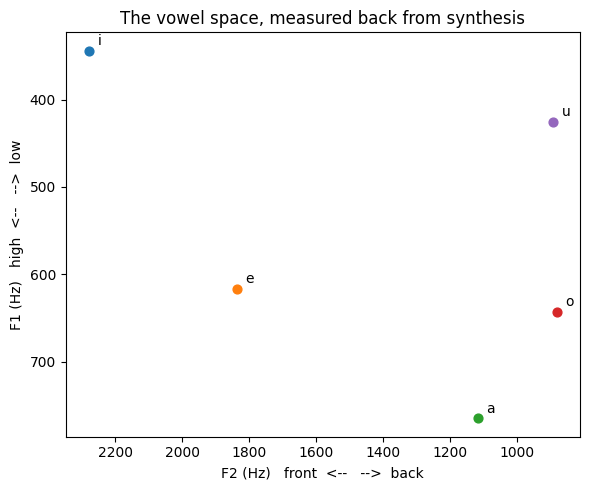

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, (f1, f2) in measured.items():
    ax.scatter(f2, f1, s=40)
    ax.annotate(name.split()[0], (f2, f1), xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('F2 (Hz)   front  <--   -->  back')
ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title('The vowel space, measured back from synthesis')
plt.tight_layout(); plt.show()

## 6. The Great Vowel Shift

The vowel space isn't only a snapshot. Vowels travel through it over time, and English ran a famous circuit. Between Chaucer and us (about 1400–1700) every long vowel rose into the slot above it; the two already at the top, *ee* and *oo*, had nowhere to go and split into the diphthongs of *ride* and *house*. That's why Chaucer's *soote* and *roote* no longer sound the way they're spelled, and why his rhymes only work in his vowels, not ours.

The figure draws the shift as arrows on the same F1/F2 map you just built: the front vowels climb one side, the back vowels climb the other, and the top two peel off into diphthongs. Whether the chain was *pulled* from the top or *pushed* from the bottom is still argued—the workbook lays out both.

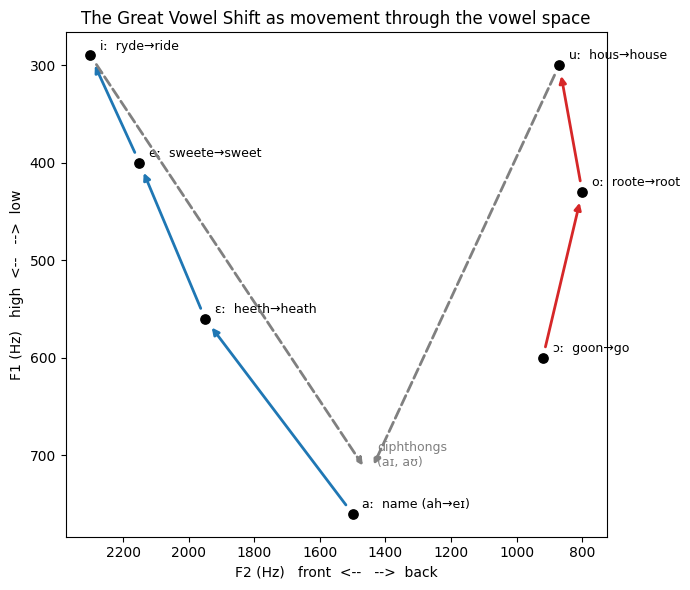

In [17]:
# Approximate Middle English long-vowel positions in (F2, F1) space.
# Schematic: the chain DIRECTION is the textbook picture, not a fresh measurement.
chain_front = ['aː', 'ɛː', 'eː', 'iː']
chain_back  = ['ɔː', 'oː', 'uː']
pos = {'iː':(2300,290),'eː':(2150,400),'ɛː':(1950,560),'aː':(1500,760),
       'uː':(870,300),'oː':(800,430),'ɔː':(920,600)}
word = {'iː':'ryde→ride','eː':'sweete→sweet','ɛː':'heeth→heath',
        'aː':'name (ah→eɪ)','uː':'hous→house','oː':'roote→root','ɔː':'goon→go'}

fig, ax = plt.subplots(figsize=(7, 6))
for v, (f2, f1) in pos.items():
    ax.scatter(f2, f1, s=45, color='black', zorder=3)
    ax.annotate(f'{v}  {word[v]}', (f2, f1), xytext=(7, 4),
                textcoords='offset points', fontsize=9)

def chain(seq, color):
    for a, b in zip(seq, seq[1:]):
        ax.annotate('', xy=pos[b], xytext=pos[a],
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=2, shrinkA=8, shrinkB=8))

chain(chain_front, 'C0')   # front vowels rise
chain(chain_back,  'C3')   # back vowels rise
for v in ['iː', 'uː']:          # the top two peel off into diphthongs
    ax.annotate('', xy=(1450, 720), xytext=pos[v],
                arrowprops=dict(arrowstyle='-|>', color='gray', lw=2, ls='--', shrinkA=8, shrinkB=8))
ax.annotate('diphthongs\n(aɪ, aʊ)', (1450, 720), xytext=(6, 6),
            textcoords='offset points', fontsize=9, color='gray')

ax.set_xlabel('F2 (Hz)   front  <--   -->  back')
ax.set_ylabel('F1 (Hz)   high  <--   -->  low')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_title('The Great Vowel Shift as movement through the vowel space')
plt.tight_layout(); plt.show()

## 7. Your own voice

Same tool, real speech—and you can record straight from your microphone, no files to wrangle. Run the next cell once to set up the recorder, then run the one after it to record a few seconds while you hold a single vowel steady (*beet*, *bat*, *boot*...). Your browser asks permission for the mic the first time. Chrome works best.

In [18]:
def mean_formants(wav_path):
    """Average F1/F2 over the steady middle of a recording."""
    snd = parselmouth.Sound(wav_path)
    fm = snd.to_formant_burg(maximum_formant=5500)
    dur = snd.get_total_duration()
    ts = np.linspace(0.3*dur, 0.7*dur, 15)
    f1 = np.nanmean([fm.get_value_at_time(1, t) for t in ts])
    f2 = np.nanmean([fm.get_value_at_time(2, t) for t in ts])
    return round(f1), round(f2)

Saving yourclip.m4a to yourclip.m4a
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --ena

Your vowel:  F1 = 321 Hz,  F2 = 2559 Hz


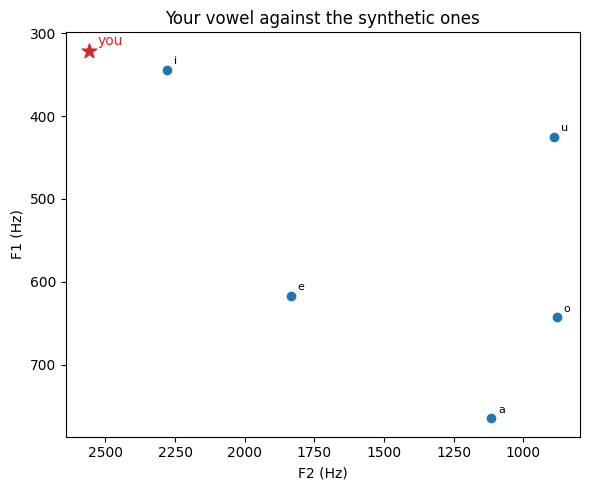

In [19]:
# Record audio and save it as myclip.m4a
from google.colab import files
files.upload()
!ffmpeg -y -i myclip.m4a -ar 16000 voice.wav
path = 'voice.wav'
display(Audio(path))                  # play it back
f1, f2 = mean_formants(path)
print(f'Your vowel:  F1 = {f1} Hz,  F2 = {f2} Hz')

# drop your vowel onto the synthetic vowel space from section 5
fig, ax = plt.subplots(figsize=(6, 5))
for name, (a, b) in measured.items():
    ax.scatter(b, a, color='C0')
    ax.annotate(name.split()[0], (b, a), xytext=(5, 4), textcoords='offset points', fontsize=8)
ax.scatter(f2, f1, color='C3', s=120, marker='*')
ax.annotate('you', (f2, f1), xytext=(6, 4), textcoords='offset points', color='C3')
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('F2 (Hz)'); ax.set_ylabel('F1 (Hz)')
ax.set_title('Your vowel against the synthetic ones')
plt.tight_layout(); plt.show()

*If the mic is blocked (some locked-down browsers or Safari can be fussy), fall back to a file: record on your phone or QuickTime, then* `from google.colab import files; files.upload()` *and* `!ffmpeg -y -i yourclip.m4a -ar 16000 voice.wav`*, then* `mean_formants('voice.wav')`*. Praat can't read m4a directly, but ffmpeg converts it in one line.*

## 8. Normalize to compare speakers

There's a catch in comparing your vowel space with someone else's. A bigger vocal tract makes every formant lower, a smaller one makes them all higher—so two people saying the very same vowels land in different places on the raw chart. The left panel below shows it: two speakers, identical vowels, two offset clouds.

To compare the *systems* instead of the *throats*, you normalize each speaker to their own range—here a simple z-score per speaker (subtract the mean, divide by the spread). The right panel shows the same data afterward: the clouds snap together, and now a real difference between speakers would actually mean something.

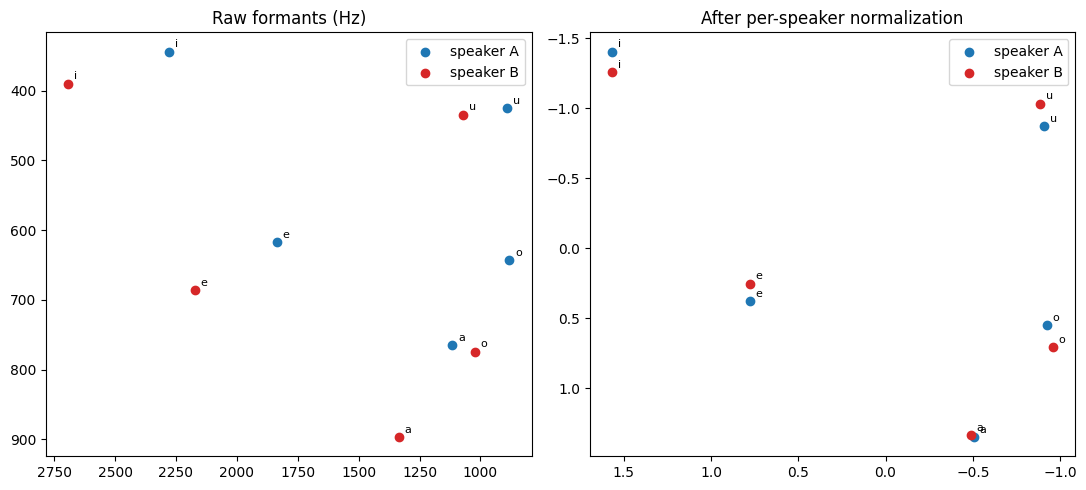

In [20]:
# Two speakers saying the same five vowels. Speaker B has a shorter vocal tract,
# so every formant comes out higher—same vowels, different numbers.
def vowel_cloud(scale=1.0):
    return {n: measure_formants(synth_vowel([(f*scale, 80) for f in F]))
            for n, F in VOWELS.items()}

spk_A = vowel_cloud(1.00)
spk_B = vowel_cloud(1.18)

def zscore(cloud):
    f1 = np.array([v[0] for v in cloud.values()])
    f2 = np.array([v[1] for v in cloud.values()])
    z1 = (f1 - f1.mean()) / f1.std()
    z2 = (f2 - f2.mean()) / f2.std()
    return {n: (a, b) for n, a, b in zip(cloud, z1, z2)}

zA, zB = zscore(spk_A), zscore(spk_B)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5))
for ax, (A, B, title) in [(axL, (spk_A, spk_B, 'Raw formants (Hz)')),
                          (axR, (zA, zB, 'After per-speaker normalization'))]:
    for cloud, color, lab in [(A, 'C0', 'A'), (B, 'C3', 'B')]:
        ax.scatter([v[1] for v in cloud.values()], [v[0] for v in cloud.values()],
                   color=color, label='speaker ' + lab)
        for n, v in cloud.items():
            ax.annotate(n.split()[0], (v[1], v[0]), xytext=(4, 3),
                        textcoords='offset points', fontsize=8)
    ax.invert_xaxis(); ax.invert_yaxis(); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 9. From sound to spelling: reading a script with a computer

Today's last idea is the subject of a study I did myself, and it pulls the whole course together. Coptic—the last stage of Egyptian—was written in Greek-derived letters that record its vowels poorly. But one medieval manuscript writes *Arabic*, a living language, in *Coptic* letters (a copy of the *Sayings of the Desert Fathers*). A fluent Coptic speaker spelling a language we can still hear, in the script we're trying to decode: a small Rosetta Stone for Coptic pronunciation.

The trap is to read it by eye—pick a word, decide which letters match, declare a result. You can "prove" almost any pronunciation that way; the examples will always oblige. So the method does the opposite. A program aligns the *whole* text, Coptic letter against Arabic letter, and measures how strongly each pair travels together (a correlation called the **phi coefficient**). Alignment and correlation feed each other for a thousand rounds, with no human intervention until the end.

The boring results are the proof it works: ⟨ⲗ⟩, ⟨ⲙ⟩, ⟨ⲛ⟩ pair with *l, m, n*, exactly as everyone already agreed. The interesting results are the payoff—⟨ⲅ⟩ (usually read *g*) lines up with [ɣ], ⟨ⲃ⟩ (usually *b*) with [w]. The toy below runs that same measurement on a handful of aligned words. The consonants are done; the vowels—using this morning's formant tools on the living Arabic dialects—are the next step.

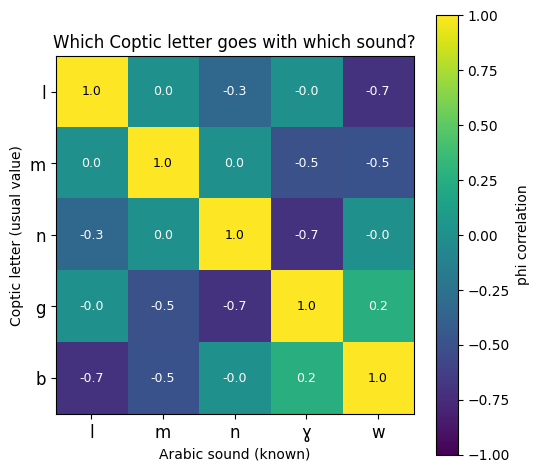

In [21]:
# A toy of the method: each 'word' is an aligned pair—which Coptic letters and
# which Arabic sounds appear together. (The real study aligns a whole manuscript
# and iterates a thousand times; here we compute the correlations once.)
words = [
    {'coptic': 'lm', 'arabic': 'lm'},
    {'coptic': 'mn', 'arabic': 'mn'},
    {'coptic': 'gl', 'arabic': 'ɣl'},
    {'coptic': 'bn', 'arabic': 'wn'},
    {'coptic': 'gb', 'arabic': 'ɣw'},
    {'coptic': 'ln', 'arabic': 'ln'},
]
cop = ['l', 'm', 'n', 'g', 'b']   # Coptic letters, by their usual value
ara = ['l', 'm', 'n', 'ɣ', 'w']   # the Arabic sounds they may line up with

# presence tables: one row per word, one column per letter/sound
C = np.array([[1 if c in w['coptic'] else 0 for c in cop] for w in words])
A = np.array([[1 if a in w['arabic'] else 0 for a in ara] for w in words])

def phi(x, y):                      # correlation of two yes/no columns
    return 0.0 if x.std() == 0 or y.std() == 0 else float(np.corrcoef(x, y)[0, 1])

M = np.array([[phi(C[:, i], A[:, j]) for j in range(len(ara))] for i in range(len(cop))])

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(M, cmap='viridis', vmin=-1, vmax=1)
ax.set_xticks(range(len(ara))); ax.set_xticklabels(ara, fontsize=12)
ax.set_yticks(range(len(cop))); ax.set_yticklabels(cop, fontsize=12)
ax.set_xlabel('Arabic sound (known)'); ax.set_ylabel('Coptic letter (usual value)')
for i in range(len(cop)):
    for j in range(len(ara)):
        ax.text(j, i, f'{M[i, j]:.1f}', ha='center', va='center',
                color='white' if M[i, j] < 0.5 else 'black', fontsize=9)
fig.colorbar(im, label='phi correlation')
ax.set_title('Which Coptic letter goes with which sound?')
plt.tight_layout(); plt.show()

### Check-in
- A formant is a resonance of the vocal tract. Why should the *shape* of the mouth, not the vocal folds, decide which vowel you hear?
- We trusted the measurement because it recovered numbers we'd put in ourselves. Is that a fair test of whether it'll work on a real recording? What might trip it up?
- Could any sound measurement bear on **your** project: loanwords, transcription, rhyme, meter?